In [123]:
# some_file.py
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '../')

import nn_fncs
mat_data = nn_fncs.read_mat_workspace('./NewData/motorModelControl1.mat') # data sampled at 1e-4s, only 100 trajectories

motor_p = mat_data.get('motor_p_out')

input_data = motor_p[:,:, 1:4]
output_data = motor_p[:,:, 0]

desired_theta = motor_p[:, :, 6]

# print input and output data shapes
print(f'input_data shape: {input_data.shape}')  # (num_trajectories, num_time_steps, PID errors)
print(f'output_data shape: {output_data.shape}')  # (num_trajectories, num_time_steps, u signals)


c:\Users\brend\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\io\matlab\_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


input_data shape: (500, 5000, 3)
output_data shape: (500, 5000)


C:\Users\brend\AppData\Local\Temp\ipykernel_45548\2623862498.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


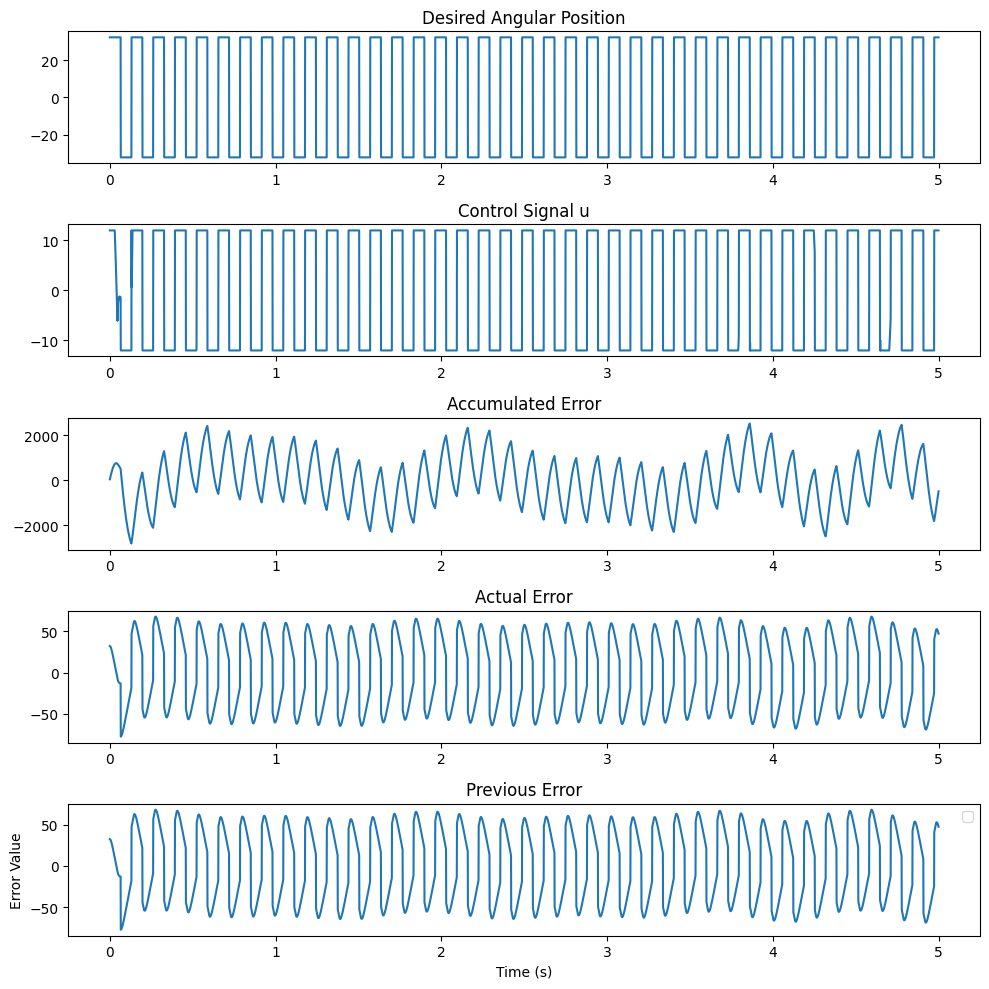

In [124]:
# Display random trajectory input and output data in a graph
from random import randint
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
# Select a random trajectory index
# random_trajectory = randint(0, input_data.shape[0] - 1)
random_trajectory = 184  # For consistent results during testing
time = [t * 1e-3 for t in range(input_data.shape[1])]
plt.figure(figsize=(10, 10))
plt.subplot(5, 1, 1)
plt.plot(time, desired_theta[random_trajectory, :])
plt.title(f'Desired Angular Position')
plt.subplot(5, 1, 2)
plt.plot(time, output_data[random_trajectory, :])
plt.title(f'Control Signal u')
plt.subplot(5, 1, 3)
plt.plot(time, input_data[random_trajectory, :, 0])
plt.title(f'Accumulated Error')
plt.subplot(5  , 1, 4)
plt.plot(time, input_data[random_trajectory, :, 1])
plt.title(f'Actual Error')
plt.subplot(5, 1, 5)
plt.plot(time, input_data[random_trajectory, :, 2])
plt.title(f'Previous Error')
plt.xlabel('Time (s)')
plt.ylabel('Error Value')   
plt.legend()
plt.tight_layout()
plt.show()

In [125]:
input_data = input_data.reshape(-1, input_data.shape[2])
output_data = output_data.reshape(-1, 1)
print(f'input_data reshaped: {input_data.shape}')  # (num_trajectories * num_time_steps, PID errors)
print(f'output_data reshaped: {output_data.shape}')  # (num_trajectories * num_time_steps, 1)

input_data reshaped: (2500000, 3)
output_data reshaped: (2500000, 1)


In [126]:
# Load the scalers if they exist
import joblib
input_scaler = joblib.load('./ControlScalers/input_scaler.pkl')
output_scaler = joblib.load('./ControlScalers/output_scaler.pkl')
# Print scalers parameters
print(f'Input Scaler Mean: {input_scaler.mean_}, Scale: {input_scaler.scale_}')
print(f'Output Scaler Mean: {output_scaler.mean_}, Scale: {output_scaler.scale_}')

Input Scaler Mean: [-0.43673171 -0.00172146 -0.00172146], Scale: [88.81345713  2.11033451  2.11033451]
Output Scaler Mean: [0.03779174], Scale: [1.58361619]


In [127]:
# Scale the data
import numpy as np

val_input = input_scaler.transform(input_data)
val_output = output_scaler.transform(output_data)

# Print max abs values after scaling
print(f'Max abs input after scaling: {np.max(np.abs(val_input), axis=0)}')
print(f'Max abs output after scaling: {np.max(np.abs(val_output), axis=0)}')

Max abs input after scaling: [1511.48426633  243.60500617  243.60500617]
Max abs output after scaling: [7.60145786]


In [128]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 32
class ControlModelv2(nn.Module):
    def __init__(self, input_size=3, output_size=1, n_neurons=n_neurons):  
        super(ControlModelv2, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, output_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, errors):
        dx = F.relu(self.fc1(errors))
        dx = self.dropout(dx)
        dx = F.relu(self.fc2(dx))
        dx = self.output(dx)
        return dx

# Create the model
model = ControlModelv2()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

ControlModelv2(
  (fc1): Linear(in_features=3, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 1217


In [129]:
# One step validation
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_validation(model, input_data, target_data):
    model.eval()
    with torch.no_grad():
        # Forward pass
        pred = model(input_data)  # Integrate over a small time step
        loss = mean_squared_error(pred, target_data)  # Compare with the next state
    r2 = r2_score(pred, target_data)
    return pred, loss, r2

In [130]:
# One step validation
from torcheval.metrics.functional import mean_squared_error, r2_score
from scipy.integrate import odeint

def one_step_validation_clip(model, input_data, target_data):
    model.eval()
    with torch.no_grad():
        # Forward pass
        pred = torch.clip(model(input_data), min=-7.60145786, max=7.60145786)  # Integrate over a small time step
        loss = mean_squared_error(pred, target_data)  # Compare with the next state
    r2 = r2_score(pred, target_data)
    return pred, loss, r2

In [131]:
# Load the trained model weights
model.load_state_dict(torch.load("control_model_v2_retrained2.pth"))

<All keys matched successfully>

In [132]:
# Test model with random u_signals validation data

id = randint(0, val_input.shape[0] - 1)
input_data = torch.tensor(val_input, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(val_output, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation(model, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

Test Loss: 5.700214385986328, R2 Score: 0.8121490478515625


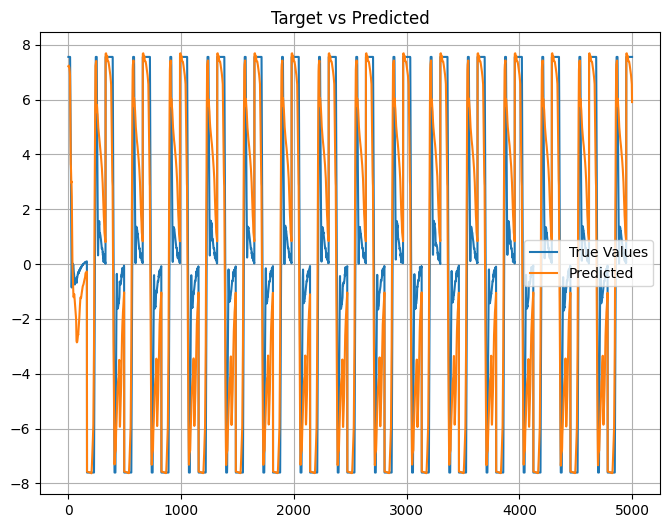

In [133]:
# Plot target vs predicted
plt.figure(figsize=(8, 6))
plt.plot(target_data[-5000:].cpu().numpy(), label='True Values')
plt.plot(pred[-5000:].cpu().numpy(), label='Predicted')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()

In [134]:
import nn_fncs
mat_data = nn_fncs.read_mat_workspace('../ForwardSwimmingSimData/forwardSwimmingComplete.mat')
motor_p = mat_data.get('motor_pout1')

input_data = motor_p[:, 1:4]
output_data = motor_p[:, 0].reshape(-1, 1)

input_data = input_scaler.transform(input_data)
output_data = output_scaler.transform(output_data)

In [135]:
# Test model with random u_signals validation data

input_data = torch.tensor(input_data, dtype=torch.float32) # Add batch dimension
target_data = torch.tensor(output_data, dtype=torch.float32)  # Add batch dimension

pred, loss, r2 = one_step_validation_clip(model, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

Test Loss: 0.990130603313446, R2 Score: 0.8196216225624084


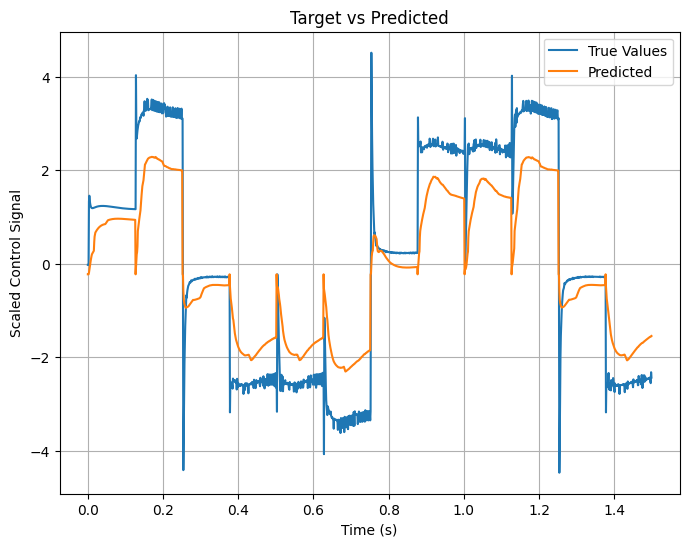

In [136]:
# Plot target vs predicted
time = [t * 1e-3 for t in range(input_data.shape[0])]
plt.figure(figsize=(8, 6))
plt.plot(time, target_data[:].cpu().numpy(), label='True Values')
plt.plot(time, pred[:].cpu().numpy(), label='Predicted')
plt.xlabel('Time (s)')
plt.ylabel('Scaled Control Signal')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()

In [137]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

n_neurons = 10
class ControlModelv3(nn.Module):
    def __init__(self, input_size=3, output_size=1, n_neurons=n_neurons):  
        super(ControlModelv3, self).__init__()
        # Fully connected layers
        self.fc1 = nn.Linear(input_size, n_neurons) 
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, n_neurons)
        self.fc4 = nn.Linear(n_neurons, n_neurons)
        self.fc5 = nn.Linear(n_neurons, n_neurons)
        self.output = nn.Linear(n_neurons, output_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, errors):
        dx = F.relu(self.fc1(errors))
        dx = self.dropout(dx)
        dx = F.relu(self.fc2(dx))
        dx = F.relu(self.fc3(dx))
        dx = F.relu(self.fc4(dx))
        dx = F.relu(self.fc5(dx))
        dx = self.output(dx)
        return dx

# Create the model
model = ControlModelv3()

# Print model summary
print(model)
print(f'Total parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

ControlModelv3(
  (fc1): Linear(in_features=3, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
  (fc3): Linear(in_features=10, out_features=10, bias=True)
  (fc4): Linear(in_features=10, out_features=10, bias=True)
  (fc5): Linear(in_features=10, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)
Total parameters: 491


In [138]:
# Load the trained model weights
model.load_state_dict(torch.load("control_model_v3.pth"))

<All keys matched successfully>

Test Loss: 1.6093659400939941, R2 Score: 0.7068115472793579


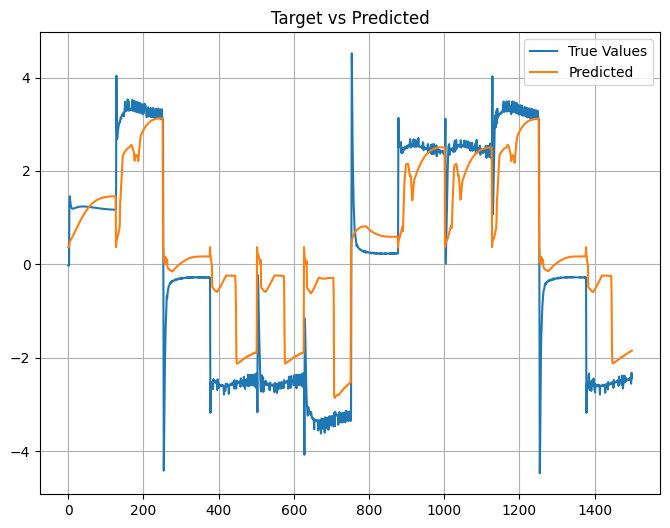

In [139]:
pred, loss, r2 = one_step_validation_clip(model, input_data, target_data)
print(f'Test Loss: {loss.item()}, R2 Score: {r2.item()}')

# Plot target vs predicted
plt.figure(figsize=(8, 6))
plt.plot(target_data[-5000:].cpu().numpy(), label='True Values')
plt.plot(pred[-5000:].cpu().numpy(), label='Predicted')
plt.legend()
plt.title('Target vs Predicted')
plt.grid()
plt.show()